# EAUI 2026 — Análisis consolidado y lineal

Notebook reorganizado para ejecución top-to-bottom sin errores.

**Secciones:**
1. Librerías y configuración
2. Carga de datos
3. Preprocesamiento (GSE, etiquetas, NS/NR, renombrado, recodificaciones, ingreso)
4. Funciones de análisis ponderado (texto plano separado por tabs)
5. Construcción de variables Q8 (niveles y tipos de habilidades)
6. Estadística descriptiva univariada (ponderada por `fe_personas` y `fe_hogar`)
7. Estadística descriptiva bivariada
8. Estadística inferencial (chi-cuadrado, V de Cramér)
9. Modelos avanzados:
   - 9.1 MCA + K-Means clustering
   - 9.2 Análisis factorial exploratorio (EFA)
   - 9.3 Clasificación supervisada (LogReg / RF / GBM)
   - 9.4 Regresión logística — coeficientes con dirección
   - 9.5 SHAP — interpretabilidad

**Factores de expansión:**
- `fe_personas` para análisis a nivel de individuos
- `fe_hogar` para análisis a nivel de hogares

## 1. Librerías y configuración

In [1]:
# Librerías base
import re
import os
import unicodedata
import warnings

import numpy as np
import pandas as pd

import pyreadstat

# Visualización (solo para modelos avanzados)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Modelos avanzados
import prince
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, OneHotEncoder, OrdinalEncoder, label_binarize
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, make_scorer, f1_score, silhouette_score
)
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, train_test_split
)

# Inferencial
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
# Forzar repr plano: que pandas NUNCA renderice DataFrames como tabla HTML
pd.set_option("display.notebook_repr_html", False)
print("Librerías cargadas")

Librerías cargadas


## 2. Carga de datos

In [2]:
# Carga del archivo SPSS
df, meta = pyreadstat.read_sav("/sessions/sweet-fervent-fermat/mnt/eaui_subtel/data/sav/2026.sav")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Filas: 5,000 | Columnas: 587


## 3. Preprocesamiento

### 3.1 GSE derivado (AIM-ESOMAR)

In [3]:
# Derivación de GSE a partir de A10 (educación jefe hogar) y A11 (ocupación jefe hogar)
def _educ_g(e):
    if pd.isna(e): return None
    e = int(e)
    if e <= 3:  return "basica"
    if e <= 7:  return "media"
    if e <= 9:  return "tecnica"
    return "universitaria"

_M = {
    (1,"basica"):"E",  (1,"media"):"E",  (1,"tecnica"):"D",  (1,"universitaria"):"D",
    (2,"basica"):"E",  (2,"media"):"D",  (2,"tecnica"):"D",  (2,"universitaria"):"C3",
    (3,"basica"):"D",  (3,"media"):"C3", (3,"tecnica"):"C3", (3,"universitaria"):"C2",
    (4,"basica"):"C3", (4,"media"):"C2", (4,"tecnica"):"C2", (4,"universitaria"):"C1",
    (5,"basica"):"C2", (5,"media"):"C1", (5,"tecnica"):"C1", (5,"universitaria"):"AB",
    (6,"basica"):"C1", (6,"media"):"AB", (6,"tecnica"):"AB", (6,"universitaria"):"AB",
}
_ORDEN_GSE = ["AB","C1","C2","C3","D","E"]

_eg = df["A10"].apply(_educ_g)
df["gse"] = pd.Categorical(
    df["A11"].combine(_eg, lambda o, e: np.nan if pd.isna(o) or e is None else _M.get((int(o), e), np.nan)),
    categories=_ORDEN_GSE, ordered=True
)
print("GSE:", df["gse"].value_counts().reindex(_ORDEN_GSE).to_dict())

GSE: {'AB': 342, 'C1': 533, 'C2': 988, 'C3': 1316, 'D': 833, 'E': 988}


### 3.2 Etiquetas limpias y diccionario de variables

In [4]:
def limpiar_etiqueta(label):
    """Extrae la parte descriptiva de una etiqueta SPSS."""
    if not label: return label
    label = label.strip()
    if re.match(r"^[A-Z]\w+[\._]\w+\s*\.-?", label):
        if ":" in label:
            r = label.split(":")[-1].strip()
            if r: return r
        if "?" in label:
            r = label.split("?")[-1].strip().lstrip(":").strip()
            if r: return r
        r = re.sub(r"^[A-Z]\w+[\._]\w+[\s\._\-]+", "", label).strip()
        return r.lstrip(".-").strip()
    if "[" in label:
        r = label[:label.index("[")].strip()
        return re.sub(r"^\d+[\.-]+\s*", "", r).strip()
    return re.sub(r"^\d+[\.-]+\s*", "", label).strip()

etiquetas_limpias = {
    col: limpiar_etiqueta(lab)
    for col, lab in zip(meta.column_names, meta.column_labels) if lab
}
diccionario = pd.DataFrame({"variable": meta.column_names, "etiqueta": meta.column_labels})
print(f"Etiquetas: {len(etiquetas_limpias)} | Diccionario: {diccionario.shape}")

Etiquetas: 587 | Diccionario: (587, 2)


### 3.3 Tratamiento de NS/NR

In [5]:
# Variables de montos usan 9999999 como código NS/NR
cols_nsnr = [
    "P11","Q7_4",
    "P17_1","P17_2","P17_3","P17_4","P17_5",
    "P19_1","P19_2","P19_3","P19_4",
    "Q40_1","Q40_2","Q40_3","Q40_4","Q40_5",
    "Q42","Q42_1"
]
for col in cols_nsnr:
    if col in df.columns:
        df[col] = df[col].replace(9999999, np.nan)
print("NS/NR reemplazados por NaN.")

NS/NR reemplazados por NaN.


### 3.4 Renombrado de variables

In [6]:
nombres_cortos = {
    "REGISTRO":"id", "FECHAFIN":"fecha_fin", "COD_REGION":"region", "COMUNA_DEF":"comuna", "ZONA":"zona",
    "A9":"parentesco_jh", "A10":"educ_jh", "A11":"ocupacion_jh", "A12_1":"ingreso_hogar",
    "Q1":"parentesco", "Q1_1":"edad", "Q1_2":"sexo", "Q1_3":"educ", "Q1_4":"ocupacion_encuestado", "Q2":"actividad",
    "P1":"acceso_internet_hogar", "P2":"n_smartphones_hogar", "P2_1":"n_computadores_hogar",
    "P10":"tipo_acceso_fijo", "P11":"pago_mensual_internet", "P11_3":"velocidad_contratada",
    "P11_4":"calidad_acceso", "P11_5":"cuota_mensual_gb", "P12_2":"tipo_plan", "P12_1":"plan_movil_tipo",
    "P14":"razon_no_acceso_principal", "P15":"disposicion_contratar_fijo",
    "Q5":"uso_computador", "Q7":"uso_smartphone", "Q7_1":"smartphone_propio",
    "Q7_3":"plan_movil_tipo_ind", "Q7_4":"pago_mensual_movil",
    "Q9":"ultimo_uso_internet", "Q10":"frecuencia_internet", "Q11":"tiempo_diario_internet",
    "Q13":"tipo_acceso_mas_usado", "Q14":"uso_internet_hogar", "Q15":"frecuencia_internet_hogar",
    "Q16":"tiempo_diario_hogar", "Q17":"uso_internet_fuera_hogar", "Q18":"frecuencia_fuera_hogar",
    "Q19":"tiempo_diario_fuera_hogar",
    "Q23":"internet_facilita_trabajo", "Q25":"internet_mejora_vida", "Q27":"ultima_compra_online",
    "Q31":"percepcion_proteccion", "Q30_1":"reg_control_legal", "Q30_2":"reg_control_familia", "Q30_3":"reg_autocontrol",
    "FE_HOGAR":"fe_hogar", "FE_PERSONAS":"fe_personas", "POND_HOGAR":"pond_hogar", "POND_PERSONAS":"pond_personas",
}
df = df.rename(columns={k: v for k, v in nombres_cortos.items() if k in df.columns})

# Mapas de educación y ocupación (jefe de hogar y encuestado)
_mapa_educ = {
    1:"Sin educación formal", 2:"Básica incompleta", 3:"Básica completa",
    4:"Media CH incompleta", 5:"Media TP incompleta", 6:"Media CH completa", 7:"Media TP completa",
    8:"Superior técnica incompleta", 9:"Superior técnica completa",
    10:"Superior universitaria incompleta", 11:"Superior universitaria completa"
}
_mapa_ocup = {
    1:"Trabajos ocasionales e informales", 2:"Oficio menor - obrero no calificado",
    3:"Obrero calificado - microempresario", 4:"Empleado medio - técnico - prof. independiente",
    5:"Ejecutivo medio - prof. universitario", 6:"Alto ejecutivo - empresario - directivo"
}
df["educ_jh"]              = df["educ_jh"].map(_mapa_educ)
df["ocupacion_jh"]         = df["ocupacion_jh"].map(_mapa_ocup)
df["ocupacion_encuestado"] = df["ocupacion_encuestado"].map({**_mapa_ocup, 7:"Sin trabajo remunerado"})
print(f"Renombradas: {len(nombres_cortos)} | Columnas: {df.shape[1]}")

Renombradas: 53 | Columnas: 588


### 3.5 Recoding de habilidades digitales (Q8)

In [7]:
# Habilidades Q8 — 0='No' / 1='Sí'
q8_vars = [
    "Q8_1","Q8_2","Q8_3","Q8_4","Q8_5","Q8_6","Q8_7","Q8_8","Q8_9","Q8_10",
    "Q8_11","Q8_12","Q8_13","Q8_14","Q8_15","Q8_16","Q8_17","Q8_18"
]
for col in q8_vars:
    if col in df.columns:
        df[col] = df[col].replace({0:"No", 1:"Sí"})
print(f"Q8 recodificadas: {len(q8_vars)} variables")

Q8 recodificadas: 18 variables


### 3.6 Recodificaciones sociodemográficas y de acceso

In [8]:
df = df.copy()

# Región y zona
df["region"] = df["region"].map({
    1:"Tarapacá", 2:"Antofagasta", 3:"Atacama", 4:"Coquimbo", 5:"Valparaíso",
    6:"O'Higgins", 7:"Maule", 8:"Biobío", 9:"Araucanía", 10:"Los Lagos",
    11:"Aysén", 12:"Magallanes", 13:"Metropolitana", 14:"Los Ríos", 15:"Arica y Parinacota", 16:"Ñuble"
})
df["zona"] = df["zona"].map({1:"Urbana", 2:"Rural"})

# Encuestado
df["sexo"] = df["sexo"].map({1:"Hombre", 2:"Mujer"})
df["educ"] = df["educ"].map(_mapa_educ)
df["educ_grupo"] = df["educ"].map({
    "Sin educación formal":"Básica o menos", "Básica incompleta":"Básica o menos",
    "Básica completa":"Básica o menos", "Media CH incompleta":"Media",
    "Media TP incompleta":"Media", "Media CH completa":"Media", "Media TP completa":"Media",
    "Superior técnica incompleta":"Superior", "Superior técnica completa":"Superior",
    "Superior universitaria incompleta":"Superior", "Superior universitaria completa":"Superior",
})
df["tramo_edad"] = pd.cut(df["edad"], bins=[0,17,29,44,59,200],
                          labels=["Menor de 18","18-29","30-44","45-59","60 y más"], right=True)
df["actividad"] = df["actividad"].map({
    1:"Trabajador independiente", 2:"Empleador/patrón", 3:"Empleado dependiente",
    4:"Familiar no remunerado", 5:"FFAA y de orden", 6:"Cesante",
    7:"Jubilado/pensionado", 8:"Estudiante", 9:"Labores del hogar"
})

# Acceso
df["acceso_internet_hogar"] = df["acceso_internet_hogar"].map({1:"Sí", 2:"No"})
df["tipo_acceso_fijo"] = df["tipo_acceso_fijo"].map({
    1:"ADSL", 2:"Cable/Módem", 3:"Fibra óptica", 4:"Inalámbrica",
    5:"Satelital", 31:"WiFi", 32:"Antena", 33:"Banda ancha", 34:"Acceso telefónico", 88:"No sabe"
})
df["velocidad_contratada"] = df["velocidad_contratada"].map({
    1:"Hasta 10 Mbps", 2:"Más de 10 a 100 Mbps", 3:"Más de 100 a 500 Mbps",
    4:"Más de 500 Mbps a 1 Gbps", 5:"Más de 1 Gbps", 99:"NS/NR"
})
df["tipo_plan"] = df["tipo_plan"].map({
    1:"Banda ancha desnuda", 2:"BA + TV Cable", 3:"BA + Telefonía fija",
    4:"Triple pack (BA+TV+Tel)", 5:"Otros planes"
})
df["tipo_acceso_mas_usado"] = df["tipo_acceso_mas_usado"].map({
    1.0:"Banda Ancha Fija / WiFi", 2.0:"Banda Ancha Móvil",
    3.0:"Internet Móvil (Smartphone/Tablet)", 4.0:"Conexión Satelital"
})

# Uso individual
df["uso_computador"]  = df["uso_computador"].map({1:"Sí", 2:"No"})
df["uso_smartphone"]  = df["uso_smartphone"].map({1:"Sí", 2:"No"})
df["ultimo_uso_internet"] = df["ultimo_uso_internet"].map({
    1:"Hoy", 2:"Entre 2 y 3 días", 3:"Entre 3 y 7 días", 4:"Entre 1 y 4 semanas",
    5:"Más de 4 semanas", 6:"Más de 12 meses", 7:"Nunca"
})
df["frecuencia_internet"] = df["frecuencia_internet"].map({
    1:"Todos los días", 2:"Varias veces por semana",
    3:"Al menos una vez al mes", 4:"Menos de una vez al mes"
})
df["tiempo_diario_internet"] = df["tiempo_diario_internet"].map({
    1:"Menos de 1 hora", 2:"Entre 1 y 2 horas", 3:"Entre 2 y 4 horas", 4:"Más de 4 horas"
})

# Percepciones
df["percepcion_proteccion"]     = df["percepcion_proteccion"].map({
    1:"Muy protegido", 2:"Protegido", 3:"Desprotegido", 4:"Muy desprotegido", 99:"NS/NR"
})
df["internet_mejora_vida"]      = df["internet_mejora_vida"].map({1:"Sí", 2:"No"})
df["internet_facilita_trabajo"] = df["internet_facilita_trabajo"].map({1:"Sí", 2:"No"})
print("Recodificaciones completadas.")

Recodificaciones completadas.


### 3.7 Ingreso del hogar (punto medio del tramo)

In [9]:
_rangos = {
    11:(0,129000),12:(130000,226000),13:(227000,393000),14:(394000,686000),15:(687000,1100000),16:(1200000,2000000),17:(2100000,None),
    21:(0,210000),22:(211000,366000),23:(367000,639000),24:(640000,1100000),25:(1200000,1900000),26:(2000000,3300000),27:(3400000,None),
    31:(0,279000),32:(280000,487000),33:(488000,849000),34:(850000,1400000),35:(1500000,2500000),36:(2600000,4500000),37:(4600000,None),
    41:(0,341000),42:(342000,595000),43:(596000,1000000),44:(1100000,1800000),45:(1900000,3100000),46:(3200000,5500000),47:(5600000,None),
    51:(0,399000),52:(400000,696000),53:(697000,1200000),54:(1300000,2100000),55:(2200000,3600000),56:(3700000,6400000),57:(6500000,None),
    61:(0,453000),62:(454000,791000),63:(792000,1300000),64:(1400000,2400000),65:(2500000,4100000),66:(4200000,7300000),67:(7400000,None),
    71:(0,505000),72:(506000,881000),73:(882000,1500000),74:(1600000,2600000),75:(2700000,4600000),76:(4700000,8100000),77:(8200000,None),
    81:(0,555000),82:(556000,967000),83:(968000,1600000),84:(1700000,2900000),85:(3000000,5100000),86:(5200000,8900000),87:(9000000,None),
    91:(0,602000),92:(603000,1000000),93:(1100000,1800000),94:(1900000,3100000),95:(3200000,5500000),96:(5600000,9700000),97:(9800000,None),
    101:(0,648000),102:(649000,1100000),103:(1200000,1900000),104:(2000000,3400000),105:(3500000,5900000),106:(6000000,10400000),107:(10500000,None),
}
_mapa_pm = {float(k): (v[0]*1.5 if v[1] is None else (v[0]+v[1])/2) for k, v in _rangos.items()}

df["ingreso_pm"] = df["ingreso_hogar"].map(_mapa_pm)
df["ingreso_tramo"] = pd.cut(
    df["ingreso_pm"],
    bins=[0, 384000, 540000, 798000, 1100000, 1700000, float("inf")],
    labels=["Hasta $384 mil","$384 mil a $540 mil","$540 mil a $798 mil",
            "$798 mil a $1,1 millón","$1,1 millón a $1,7 millones","Más de $1,7 millones"],
    right=True
)
df["ingreso_grupo"] = df["ingreso_tramo"].map({
    "Hasta $384 mil":"Bajo", "$384 mil a $540 mil":"Bajo",
    "$540 mil a $798 mil":"Medio", "$798 mil a $1,1 millón":"Medio",
    "$1,1 millón a $1,7 millones":"Alto", "Más de $1,7 millones":"Alto",
})
# Validación: promedio de ingreso por GSE (texto plano)
val = (df.groupby("gse", observed=True)["ingreso_pm"]
       .agg(N="count", Promedio="mean").reindex(_ORDEN_GSE).round(0))
print("Validación: ingreso promedio por GSE")
print(val.to_string())

Validación: ingreso promedio por GSE
        N   Promedio
gse                 
AB    286  2097505.0
C1    444  1389884.0
C2    826   986176.0
C3   1112   799533.0
D     704   650022.0
E     846   539833.0


## 4. Funciones de análisis ponderado

`dstats()` imprime una tabla con columnas alineadas (legible en Jupyter / texto plano monoespaciado) y retorna el DataFrame por si quieres asignarlo a una variable para uso posterior.

In [10]:
ORDEN_CATEGORIAS = {
    "sexo":         ["Hombre","Mujer"],
    "zona":         ["Urbana","Rural"],
    "region":       ["Tarapacá","Antofagasta","Atacama","Coquimbo","Valparaíso","O'Higgins","Maule",
                     "Biobío","Araucanía","Los Lagos","Aysén","Magallanes","Metropolitana",
                     "Los Ríos","Arica y Parinacota","Ñuble"],
    "educ":         ["Sin educación formal","Básica incompleta","Básica completa",
                     "Media CH incompleta","Media TP incompleta","Media CH completa","Media TP completa",
                     "Superior técnica incompleta","Superior técnica completa",
                     "Superior universitaria incompleta","Superior universitaria completa"],
    "educ_grupo":   ["Básica o menos","Media","Superior"],
    "tramo_edad":   ["Menor de 18","18-29","30-44","45-59","60 y más"],
    "ocupacion_jh": ["Trabajos ocasionales e informales","Oficio menor - obrero no calificado",
                     "Obrero calificado - microempresario","Empleado medio - técnico - prof. independiente",
                     "Ejecutivo medio - prof. universitario","Alto ejecutivo - empresario - directivo"],
    "ocupacion_encuestado": ["Trabajos ocasionales e informales","Oficio menor - obrero no calificado",
                     "Obrero calificado - microempresario","Empleado medio - técnico - prof. independiente",
                     "Ejecutivo medio - prof. universitario","Alto ejecutivo - empresario - directivo",
                     "Sin trabajo remunerado"],
    "gse":              ["AB","C1","C2","C3","D","E"],
    "ingreso_tramo":    ["Hasta $384 mil","$384 mil a $540 mil","$540 mil a $798 mil",
                         "$798 mil a $1,1 millón","$1,1 millón a $1,7 millones","Más de $1,7 millones"],
    "ingreso_grupo":    ["Bajo","Medio","Alto"],
    "acceso_internet_hogar":    ["Sí","No"],
    "uso_computador":           ["Sí","No"],
    "uso_smartphone":           ["Sí","No"],
    "internet_mejora_vida":     ["Sí","No"],
    "internet_facilita_trabajo":["Sí","No"],
    "frecuencia_internet":      ["Todos los días","Varias veces por semana",
                                  "Al menos una vez al mes","Menos de una vez al mes"],
    "tiempo_diario_internet":   ["Menos de 1 hora","Entre 1 y 2 horas","Entre 2 y 4 horas","Más de 4 horas"],
}


def _fmt_celda(v, col):
    """Formatea un valor según el nombre de columna (enteros para n, decimales para %)."""
    if pd.isna(v):
        return ""
    nombre = str(col).lower()
    es_entero = nombre.startswith("n ") or nombre.startswith("n_") or "ponderado" in nombre or "total" in nombre
    if es_entero:
        return f"{v:,.0f}".replace(",", ".")
    try:
        return f"{float(v):.2f}"
    except Exception:
        return str(v)


def to_pretty(df_tabla, titulo=None):
    """
    Devuelve la tabla como texto plano con columnas alineadas con espacios.
    Legible en consola/Jupyter; se puede copiar a Word manteniendo el formato.
    """
    idx_name = df_tabla.index.name if df_tabla.index.name else ""
    # Formatear todas las celdas a string
    df_str = df_tabla.copy()
    for c in df_str.columns:
        df_str[c] = df_str[c].apply(lambda v: _fmt_celda(v, c))
    # Indices y columnas como strings
    idx_vals = [str(i) for i in df_str.index]
    col_names = [str(c) for c in df_str.columns]
    # Ancho por columna (incluyendo el índice)
    ancho_idx = max([len(idx_name)] + [len(s) for s in idx_vals])
    anchos_cols = []
    for cn, c in zip(col_names, df_str.columns):
        ancho = max(len(cn), df_str[c].astype(str).str.len().max() if len(df_str) else 0)
        anchos_cols.append(ancho)
    # Armar líneas
    sep = "  "
    lineas = []
    if titulo:
        lineas.append(titulo)
        lineas.append("-" * len(titulo))
    encabezado = idx_name.ljust(ancho_idx) + sep + sep.join(cn.rjust(w) for cn, w in zip(col_names, anchos_cols))
    lineas.append(encabezado)
    lineas.append("-" * len(encabezado))
    for idx_val, (_, fila) in zip(idx_vals, df_str.iterrows()):
        linea = idx_val.ljust(ancho_idx) + sep + sep.join(str(fila[c]).rjust(w) for c, w in zip(df_str.columns, anchos_cols))
        lineas.append(linea)
    return "\n".join(lineas)


def _ordenar(df_res, var, cruzada=False):
    if var not in ORDEN_CATEGORIAS: return df_res
    orden = ORDEN_CATEGORIAS[var]
    if cruzada:
        ok  = [v for v in orden if v in df_res.index]
        rst = [v for v in df_res.index if v not in ok and v != "Total"]
        fin = ok + rst + (["Total"] if "Total" in df_res.index else [])
        return df_res.reindex(fin)
    ok  = [v for v in orden if v in df_res[var].values]
    rst = [v for v in df_res[var].values if v not in ok and v != "Total"]
    df_res[var] = pd.Categorical(df_res[var], categories=ok+rst+["Total"], ordered=True)
    return df_res.sort_values(var).reset_index(drop=True)


def _mostrar(res, titulo):
    """Imprime la tabla con columnas alineadas (texto plano)."""
    print(to_pretty(res, titulo=titulo))
    print()


def dstats(data_df, variables, tipo="frecuencia", cruce=None, factor=None,
           transponer=False, imprimir=True):
    """
    Análisis ponderado. Devuelve un DataFrame.

    tipo: "frecuencia" | "cruzada" | "promedio" | "suma"
    factor: "fe_personas" para individuos, "fe_hogar" para hogares
    imprimir=True imprime tabla alineada y muestra DataFrame HTML.
    """
    if isinstance(variables, str):
        variables = [variables]
    for col in variables + [factor] + ([cruce] if cruce else []):
        if col not in data_df.columns:
            raise ValueError(f"Columna '{col}' no existe.")

    if tipo == "frecuencia":
        var = variables[0]
        tot = data_df[factor].sum()
        res = (data_df.groupby(var, observed=True)[factor].sum()
               .reset_index().rename(columns={factor:"n_ponderado"}))
        res["porcentaje"] = (res["n_ponderado"] / tot * 100).round(2)
        res = _ordenar(res, var).set_index(var)
        titulo = f"Frecuencia: '{var}' — base ponderada: {int(tot):,} ({factor})"
        if imprimir: _mostrar(res, titulo)
        return res

    if tipo == "cruzada":
        var = variables[0]
        tot = data_df[factor].sum()
        t  = data_df.pivot_table(values=factor, index=var, columns=cruce,
                                 aggfunc="sum", fill_value=0, observed=False)
        tp = t.div(t.sum(axis=0), axis=1).mul(100).round(2)
        if var in ORDEN_CATEGORIAS:
            of = [v for v in ORDEN_CATEGORIAS[var] if v in t.index]
            t, tp = t.reindex(of), tp.reindex(of)
        if cruce in ORDEN_CATEGORIAS:
            oc = [v for v in ORDEN_CATEGORIAS[cruce] if v in t.columns]
            t, tp = t[oc], tp[oc]
        if transponer:
            t, tp = t.T, tp.T
        cols = []
        for c in t.columns:
            cols.append(t[c].rename(f"n {c}"))
            cols.append(tp[c].rename(f"% {c}"))
        res = pd.concat(cols, axis=1)
        titulo = f"Cruce: '{var}' x '{cruce}' — base ponderada: {int(tot):,} ({factor})"
        if imprimir: _mostrar(res, titulo)
        return res

    def _wavg(sub, v, f):
        d = sub[[v, f]].dropna()
        return float(round(np.average(d[v], weights=d[f]), 4)) if len(d) > 0 and d[f].sum() > 0 else np.nan

    def _wsum(sub, v, f):
        d = sub[[v, f]].dropna()
        return float(round((d[v]*d[f]).sum(), 4))

    fn = _wavg if tipo == "promedio" else _wsum
    col_name = "promedio_ponderado" if tipo == "promedio" else "suma_ponderada"

    if not cruce:
        res = pd.DataFrame([(v, fn(data_df, v, factor)) for v in variables],
                           columns=["variable", col_name]).set_index("variable")
        titulo = f"{tipo.capitalize()} de variables — factor: {factor}"
        if imprimir: _mostrar(res, titulo)
        return res

    filas = {g: {v: fn(sg, v, factor) for v in variables}
             for g, sg in data_df.groupby(cruce, observed=True)}
    res = pd.DataFrame(filas).T
    res.index.name = cruce
    if cruce in ORDEN_CATEGORIAS:
        ok  = [v for v in ORDEN_CATEGORIAS[cruce] if v in res.index]
        rst = [v for v in res.index if v not in ok]
        res = res.reindex(ok + rst)
    titulo = f"{tipo.capitalize()} cruzado por '{cruce}' — factor: {factor}"
    if imprimir: _mostrar(res, titulo)
    return res

print("Funciones listas: dstats, to_pretty, _mostrar")

Funciones listas: dstats, to_pretty, _mostrar


## 5. Construcción de variables Q8 (nivel y tipo de habilidades)

In [11]:
# Clasificación por nivel de dificultad
Q8_BASICO = {
    "Q8_10":"Streaming","Q8_11":"Juegos en línea","Q8_12":"Revisar RRSS",
    "Q8_13":"Publicar RRSS","Q8_15":"Videollamadas","Q8_16":"Correo electrónico",
}
Q8_INTERMEDIO = {
    "Q8_1":"Word","Q8_2":"Excel","Q8_3":"PowerPoint","Q8_4":"Transferir / nube",
    "Q8_5":"Conectar dispositivo","Q8_6":"Instalar apps","Q8_14":"Editar fotos/videos",
    "Q8_17":"Pagos en línea","Q8_18":"Uso de IA",
}
Q8_AVANZADO = {
    "Q8_7":"Seguridad del dispositivo","Q8_8":"Instalar SO / programar","Q8_9":"Crear sitio web",
}
_cols_b = list(Q8_BASICO); _cols_i = list(Q8_INTERMEDIO); _cols_a = list(Q8_AVANZADO)
_cols_q8 = _cols_b + _cols_i + _cols_a

def _nivel(row):
    if any(row[c] == "Sí" for c in _cols_a if pd.notna(row[c])): return "Avanzado"
    if any(row[c] == "Sí" for c in _cols_i if pd.notna(row[c])): return "Intermedio"
    if any(row[c] == "Sí" for c in _cols_b if pd.notna(row[c])): return "Básico"
    return "Sin habilidades"

df["nivel_habilidades"] = df.apply(_nivel, axis=1)
ORDEN_CATEGORIAS["nivel_habilidades"] = ["Sin habilidades","Básico","Intermedio","Avanzado"]
print(df["nivel_habilidades"].value_counts())

nivel_habilidades
Intermedio         2226
Avanzado           1548
Básico              805
Sin habilidades     421
Name: count, dtype: int64


In [12]:
# Variables tiene_X — al menos una habilidad en cada categoría
def _tiene(cols):
    return df[cols].apply(lambda row: any(row[c] == "Sí" for c in cols if pd.notna(row[c])), axis=1).astype(int)

df["tiene_basicas"]      = _tiene(_cols_b)
df["tiene_intermedias"]  = _tiene(_cols_i)
df["tiene_avanzadas"]    = _tiene(_cols_a)

# Tipos por propósito
Q8_PRODUCTIVAS    = ["Q8_1","Q8_2","Q8_3","Q8_4","Q8_5","Q8_6","Q8_7","Q8_8","Q8_17","Q8_18"]
Q8_RECREATIVAS    = ["Q8_10","Q8_11"]
Q8_CREATIVIDAD    = ["Q8_9","Q8_14"]
Q8_COMUNICACIONES = ["Q8_12","Q8_13","Q8_15","Q8_16"]
df["tiene_productivas"]    = _tiene(Q8_PRODUCTIVAS)
df["tiene_recreativas"]    = _tiene(Q8_RECREATIVAS)
df["tiene_creatividad"]    = _tiene(Q8_CREATIVIDAD)
df["tiene_comunicaciones"] = _tiene(Q8_COMUNICACIONES)

# Persona "sin ninguna habilidad"
df["no_hab"] = (df[_cols_q8].apply(lambda r: all(r[c] != "Sí" for c in _cols_q8 if pd.notna(r[c])), axis=1)).map({True:"Sí", False:"No"})
print(df[["tiene_basicas","tiene_intermedias","tiene_avanzadas",
          "tiene_productivas","tiene_recreativas","tiene_creatividad","tiene_comunicaciones"]].sum())

tiene_basicas           4443
tiene_intermedias       3764
tiene_avanzadas         1548
tiene_productivas       3632
tiene_recreativas       2604
tiene_creatividad       2536
tiene_comunicaciones    4400
dtype: int64


## 6. Estadística descriptiva univariada

A nivel **individuos** se usa `fe_personas`; a nivel **hogares** se usa `fe_hogar`.

### 6.1 Individuos (fe_personas)

In [13]:
vars_individuos = ["sexo", "tramo_edad", "educ", "educ_grupo", "ocupacion_encuestado",
                   "gse", "zona", "region", "uso_computador", "uso_smartphone",
                   "frecuencia_internet", "tiempo_diario_internet", "nivel_habilidades"]
for v in vars_individuos:
    if v in df.columns:
        dstats(df, v, tipo="frecuencia", factor="fe_personas")
pass

Frecuencia: 'sexo' — base ponderada: 13,810,761 (fe_personas)
-------------------------------------------------------------
sexo    n_ponderado  porcentaje
-------------------------------
Hombre    6.681.550       48.38
Mujer     7.129.211       51.62

Frecuencia: 'tramo_edad' — base ponderada: 13,810,761 (fe_personas)
-------------------------------------------------------------------
tramo_edad   n_ponderado  porcentaje
------------------------------------
Menor de 18      165.664        1.20
18-29          3.563.036       25.80
30-44          4.122.884       29.85
45-59          2.909.848       21.07
60 y más       3.049.329       22.08

Frecuencia: 'educ' — base ponderada: 13,810,761 (fe_personas)
-------------------------------------------------------------
educ                               n_ponderado  porcentaje
----------------------------------------------------------
Sin educación formal                    46.502        0.34
Básica incompleta                      591.671    

### 6.2 Hogares (fe_hogar)

In [14]:
vars_hogares = ["region", "zona", "gse", "ingreso_tramo", "ingreso_grupo",
                "educ_jh", "ocupacion_jh", "acceso_internet_hogar",
                "tipo_acceso_fijo", "velocidad_contratada", "tipo_plan",
                "tipo_acceso_mas_usado"]
for v in vars_hogares:
    if v in df.columns:
        dstats(df, v, tipo="frecuencia", factor="fe_hogar")
pass

Frecuencia: 'region' — base ponderada: 5,651,637 (fe_hogar)
-----------------------------------------------------------
region              n_ponderado  porcentaje
-------------------------------------------
Tarapacá                 97.693        1.73
Antofagasta             174.314        3.08
Atacama                  88.706        1.57
Coquimbo                240.317        4.25
Valparaíso              608.949       10.77
O'Higgins               301.717        5.34
Maule                   351.509        6.22
Biobío                  507.241        8.98
Araucanía               317.525        5.62
Los Lagos               277.482        4.91
Aysén                    34.609        0.61
Magallanes               53.832        0.95
Metropolitana         2.238.179       39.60
Los Ríos                128.984        2.28
Arica y Parinacota       66.842        1.18
Ñuble                   163.738        2.90

Frecuencia: 'zona' — base ponderada: 5,651,637 (fe_hogar)
-----------------------------

## 7. Estadística descriptiva bivariada

### 7.1 Habilidades digitales según sociodemografía (fe_personas)

In [15]:
cruces_personas = [
    ("nivel_habilidades", "sexo"),
    ("nivel_habilidades", "tramo_edad"),
    ("nivel_habilidades", "educ_grupo"),
    ("nivel_habilidades", "gse"),
    ("nivel_habilidades", "zona"),
    ("nivel_habilidades", "ocupacion_encuestado"),
]
for var, cruce in cruces_personas:
    dstats(df, var, cruce=cruce, tipo="cruzada", factor="fe_personas")
pass

Cruce: 'nivel_habilidades' x 'sexo' — base ponderada: 13,810,761 (fe_personas)
------------------------------------------------------------------------------
nivel_habilidades   n Hombre  % Hombre    n Mujer  % Mujer
----------------------------------------------------------
Sin habilidades      377.047      5.64    456.051     6.40
Básico               650.295      9.73    934.725    13.11
Intermedio         2.371.287     35.49  3.339.711    46.85
Avanzado           3.282.921     49.13  2.398.723    33.65

Cruce: 'nivel_habilidades' x 'tramo_edad' — base ponderada: 13,810,761 (fe_personas)
------------------------------------------------------------------------------------
nivel_habilidades  n Menor de 18  % Menor de 18    n 18-29  % 18-29    n 30-44  % 30-44    n 45-59  % 45-59  n 60 y más  % 60 y más
-----------------------------------------------------------------------------------------------------------------------------------
Sin habilidades                0           0.00     1

### 7.2 Acceso a internet del hogar según sociodemografía (fe_hogar)

In [16]:
cruces_hogares = [
    ("acceso_internet_hogar", "gse"),
    ("acceso_internet_hogar", "zona"),
    ("acceso_internet_hogar", "region"),
    ("acceso_internet_hogar", "ingreso_grupo"),
    ("tipo_acceso_fijo",      "gse"),
    ("velocidad_contratada",  "gse"),
]
for var, cruce in cruces_hogares:
    dstats(df, var, cruce=cruce, tipo="cruzada", factor="fe_hogar")
pass

Cruce: 'acceso_internet_hogar' x 'gse' — base ponderada: 5,651,637 (fe_hogar)
-----------------------------------------------------------------------------
acceso_internet_hogar     n AB   % AB     n C1   % C1       n C2   % C2       n C3   % C3      n D    % D      n E    % E
-------------------------------------------------------------------------------------------------------------------------
Sí                     564.938  99.84  705.229  99.17  1.254.131  98.93  1.302.498  96.07  849.683  95.35  781.007  90.80
No                         899   0.16    5.896   0.83     13.612   1.07     53.223   3.93   41.430   4.65   79.091   9.20

Cruce: 'acceso_internet_hogar' x 'zona' — base ponderada: 5,651,637 (fe_hogar)
------------------------------------------------------------------------------
acceso_internet_hogar   n Urbana  % Urbana  n Rural  % Rural
------------------------------------------------------------
Sí                     4.792.411     96.77  665.075    95.10
No            

## 8. Estadística inferencial

Test chi-cuadrado y V de Cramér sobre tablas **no ponderadas** (los tests asumen casos independientes). Se reportan los pares de variables sociodemográficas vs. nivel de habilidades y acceso a internet.

In [17]:
def cramers_v(tabla):
    """V de Cramér a partir de una tabla de contingencia."""
    chi2, p, dof, _ = stats.chi2_contingency(tabla)
    n = tabla.values.sum()
    r, k = tabla.shape
    denom = n * (min(r, k) - 1)
    v = np.sqrt(chi2 / denom) if denom > 0 else np.nan
    return chi2, p, dof, v


def test_pares(df_, pares):
    filas = []
    for var, cruce in pares:
        sub = df_[[var, cruce]].dropna()
        tabla = pd.crosstab(sub[var], sub[cruce])
        if tabla.size == 0:
            continue
        chi2, p, dof, v = cramers_v(tabla)
        filas.append({
            "variable": var, "cruce": cruce, "n": int(tabla.values.sum()),
            "chi2": round(chi2, 2), "gl": dof,
            "p_valor": p, "cramers_v": round(v, 3),
            "signif": "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
        })
    res = pd.DataFrame(filas).set_index(["variable","cruce"])
    print(to_pretty(res, titulo="Tests chi-cuadrado y V de Cramér"))
    print()
    return res

pares_inferencial = [
    ("nivel_habilidades", "sexo"),
    ("nivel_habilidades", "tramo_edad"),
    ("nivel_habilidades", "educ_grupo"),
    ("nivel_habilidades", "gse"),
    ("nivel_habilidades", "zona"),
    ("acceso_internet_hogar", "gse"),
    ("acceso_internet_hogar", "zona"),
    ("acceso_internet_hogar", "region"),
    ("acceso_internet_hogar", "ingreso_grupo"),
]
test_pares(df, pares_inferencial)
pass

Tests chi-cuadrado y V de Cramér
--------------------------------
                                                  n     chi2     gl  p_valor  cramers_v  signif
-----------------------------------------------------------------------------------------------
('nivel_habilidades', 'sexo')               5000.00    68.80   3.00     0.00       0.12     ***
('nivel_habilidades', 'tramo_edad')         5000.00  1531.12  12.00     0.00       0.32     ***
('nivel_habilidades', 'educ_grupo')         5000.00  1748.56   6.00     0.00       0.42     ***
('nivel_habilidades', 'gse')                5000.00   952.34  15.00     0.00       0.25     ***
('nivel_habilidades', 'zona')               5000.00    31.15   3.00     0.00       0.08     ***
('acceso_internet_hogar', 'gse')            5000.00    87.44   5.00     0.00       0.13     ***
('acceso_internet_hogar', 'zona')           5000.00     6.08   1.00     0.01       0.04       *
('acceso_internet_hogar', 'region')         5000.00    58.00  15.00   

## 9. Modelos avanzados

### 9.1 MCA + K-Means clustering

MCA sobre habilidades + sociodemografía (a nivel personas, sin ponderación porque sklearn/prince no la soportan nativamente; se mantiene `fe_personas` solo para tabular post-hoc).

In [18]:
vars_hab   = ["tiene_basicas","tiene_intermedias","tiene_avanzadas",
              "tiene_productivas","tiene_recreativas","tiene_creatividad","tiene_comunicaciones"]
vars_socio = ["gse","educ_grupo","zona"]
vars_mca   = vars_hab + vars_socio

df_mca = df[vars_mca + ["fe_personas"]].dropna().copy()

# Variables tiene_X a strings Sí/No, sociodemográficas a string
for v in vars_hab:
    df_mca[v] = df_mca[v].map({1:"Sí", 0:"No"}).fillna("No")
for v in vars_socio:
    df_mca[v] = df_mca[v].astype(str)

print(f"Casos para MCA: {len(df_mca):,} de {len(df):,}")

mca = prince.MCA(n_components=3, random_state=42)
mca = mca.fit(df_mca[vars_mca])

eig = list(mca.eigenvalues_)
total = sum(eig)
print("\nDim\teigenvalue\t% inercia")
for i, e in enumerate(eig, 1):
    print(f"{i}\t{e:.4f}\t{e/total*100:.2f}")

Casos para MCA: 5,000 de 5,000



Dim	eigenvalue	% inercia
1	0.4339	59.96
2	0.1575	21.77
3	0.1322	18.27


In [19]:
# Coordenadas individuales
coords_ind = mca.row_coordinates(df_mca[vars_mca])
coords_ind.columns = [f"Dim{i+1}" for i in range(coords_ind.shape[1])]

# Selección de k con silhouette
ks = list(range(2, 8))
sil = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(coords_ind)
    sil.append(silhouette_score(coords_ind, km.labels_))
    print(f"k={k}\tsilhouette={sil[-1]:.3f}")
k_opt = ks[int(np.argmax(sil))]
print(f"\nk óptimo: {k_opt}")

kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10).fit(coords_ind)
df_mca["cluster"] = kmeans.labels_
print("\nDistribución de clusters:")
print(df_mca["cluster"].value_counts().sort_index())

k=2	silhouette=0.478


k=3	silhouette=0.419


k=4	silhouette=0.447


k=5	silhouette=0.387


k=6	silhouette=0.391


k=7	silhouette=0.396

k óptimo: 2

Distribución de clusters:
cluster
0    3542
1    1458
Name: count, dtype: int64


In [20]:
# Caracterización ponderada de los clusters
for v in vars_socio + ["tiene_basicas","tiene_intermedias","tiene_avanzadas"]:
    if v not in df_mca.columns: continue
    tabla = pd.crosstab(df_mca[v], df_mca["cluster"],
                        values=df_mca["fe_personas"], aggfunc="sum")
    tabla_p = tabla.div(tabla.sum(axis=0), axis=1) * 100
    print(to_pretty(tabla_p.round(2), titulo=f"% por cluster — variable: {v}"))
    print()

% por cluster — variable: gse
-----------------------------
gse      0      1
-----------------
AB   13.15   2.88
C1   16.04   3.14
C2   25.90  12.87
C3   23.22  24.77
D    12.46  25.53
E     9.22  30.80

% por cluster — variable: educ_grupo
------------------------------------
educ_grupo          0      1
----------------------------
Básica o menos   3.37  40.67
Media           40.81  47.79
Superior        55.82  11.54

% por cluster — variable: zona
------------------------------
zona        0      1
--------------------
Rural   11.41  16.07
Urbana  88.59  83.93

% por cluster — variable: tiene_basicas
---------------------------------------
tiene_basicas      0      1
---------------------------
No              0.01  39.11
Sí             99.99  60.89

% por cluster — variable: tiene_intermedias
-------------------------------------------
tiene_intermedias      0      1
-------------------------------
No                  0.25  84.22
Sí                 99.75  15.78

% por cluster — va

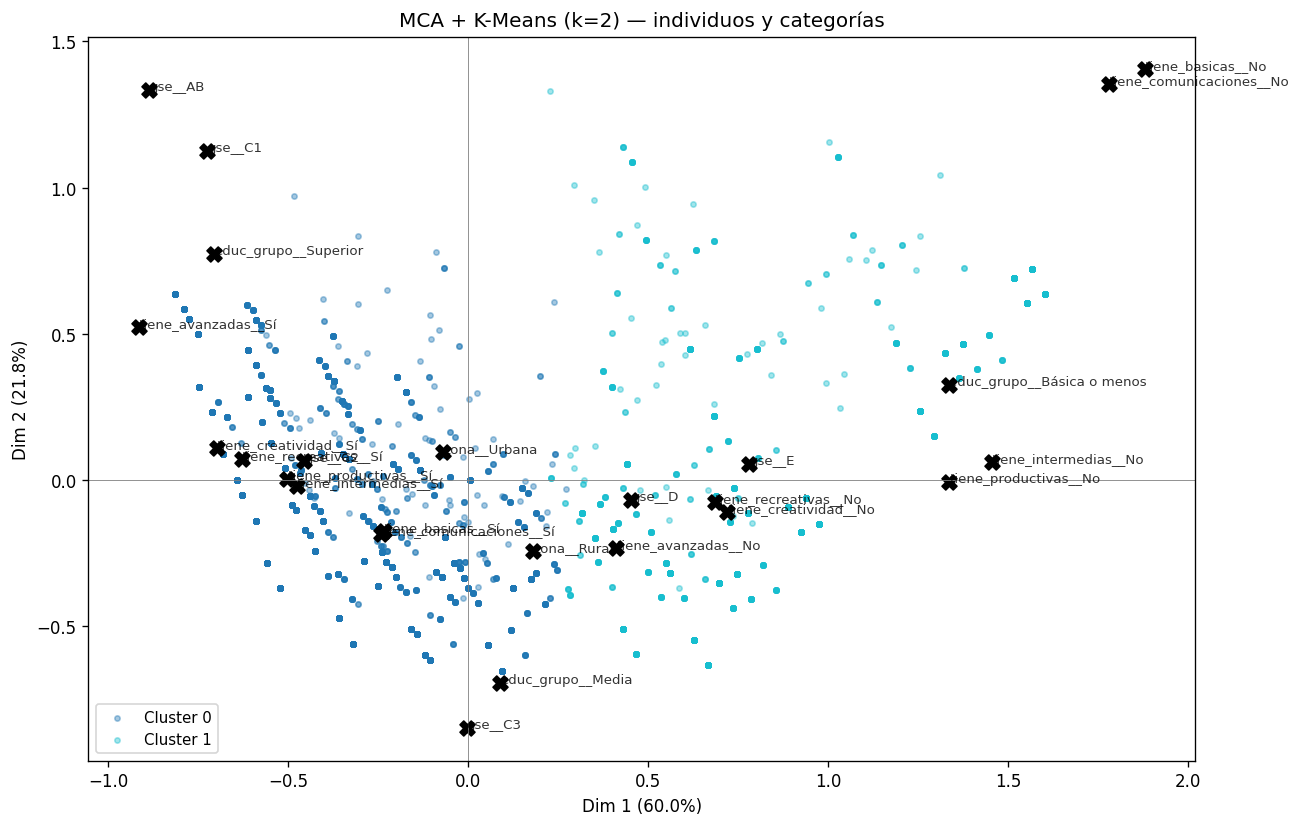

In [21]:
# Visualización del biplot MCA + clusters
fig, ax = plt.subplots(figsize=(11, 7), dpi=120)
colores = plt.cm.tab10(np.linspace(0, 1, k_opt))

for c in sorted(df_mca["cluster"].unique()):
    mask = df_mca["cluster"] == c
    ax.scatter(coords_ind.loc[mask, "Dim1"], coords_ind.loc[mask, "Dim2"],
               s=10, alpha=0.4, color=colores[c], label=f"Cluster {c}")

# Loadings de categorías
coords_cat = mca.column_coordinates(df_mca[vars_mca])
coords_cat.columns = [f"Dim{i+1}" for i in range(coords_cat.shape[1])]
ax.scatter(coords_cat["Dim1"], coords_cat["Dim2"], s=80, c="black", marker="X")
for nombre, fila in coords_cat.iterrows():
    ax.annotate(nombre, (fila["Dim1"], fila["Dim2"]), fontsize=8, alpha=0.8)

pct1 = eig[0]/total*100
pct2 = eig[1]/total*100
ax.set_xlabel(f"Dim 1 ({pct1:.1f}%)")
ax.set_ylabel(f"Dim 2 ({pct2:.1f}%)")
ax.set_title(f"MCA + K-Means (k={k_opt}) — individuos y categorías")
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

### 9.2 Análisis factorial exploratorio (EFA)

In [22]:
# EFA sobre la matriz binaria de habilidades Q8 (Sí=1, No=0)
# Útil para identificar dimensiones latentes que agrupen ítems Q8.
try:
    from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "factor_analyzer"])
    from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo

cols_q8_bin = _cols_q8
X_efa = df[cols_q8_bin].apply(lambda s: s.map({"Sí":1, "No":0})).dropna()
print(f"Casos EFA: {len(X_efa):,} | Variables: {len(cols_q8_bin)}")

# Adecuación
chi2_b, p_b = calculate_bartlett_sphericity(X_efa)
kmo_items, kmo_total = calculate_kmo(X_efa)
print(f"Bartlett: chi2={chi2_b:.1f} p={p_b:.4f}")
print(f"KMO total: {kmo_total:.3f}")

Casos EFA: 4,758 | Variables: 18
Bartlett: chi2=46811.2 p=0.0000
KMO total: 0.958


In [23]:
# Selección de número de factores: scree plot vs Kaiser
fa_temp = FactorAnalyzer(n_factors=len(cols_q8_bin), rotation=None)
fa_temp.fit(X_efa)
eigen, _ = fa_temp.get_eigenvalues()
print("Eigenvalues:", np.round(eigen, 3))
n_factores = int(np.sum(eigen > 1))
print(f"Factores con eigenvalue > 1: {n_factores}")

# Ajuste final con rotación varimax
fa = FactorAnalyzer(n_factors=n_factores, rotation="varimax")
fa.fit(X_efa)
cargas = pd.DataFrame(fa.loadings_, index=cols_q8_bin,
                      columns=[f"F{i+1}" for i in range(n_factores)])
print(to_pretty(cargas.round(3), titulo=f"Cargas factoriales (varimax, {n_factores} factores)"))

# Varianza explicada
var_exp = fa.get_factor_variance()
var_df = pd.DataFrame({
    "Eigenvalue": var_exp[0],
    "% Varianza": var_exp[1]*100,
    "% Acumulada": var_exp[2]*100
}, index=[f"F{i+1}" for i in range(n_factores)])
print(to_pretty(var_df.round(3), titulo="Varianza explicada por factor"))

Eigenvalues: [8.436 1.511 1.121 0.77  0.711 0.668 0.586 0.55  0.516 0.469 0.46  0.414
 0.342 0.335 0.3   0.282 0.273 0.255]
Factores con eigenvalue > 1: 3
Cargas factoriales (varimax, 3 factores)
----------------------------------------
         F1    F2    F3
-----------------------
Q8_10  0.23  0.33  0.32
Q8_11  0.34  0.34  0.42
Q8_12  0.09  0.52  0.10
Q8_13  0.35  0.57  0.28
Q8_15  0.06  0.59  0.09
Q8_16  0.43  0.61  0.14
Q8_1   0.76  0.27  0.19
Q8_2   0.74  0.20  0.24
Q8_3   0.78  0.21  0.30
Q8_4   0.69  0.28  0.35
Q8_5   0.71  0.30  0.33
Q8_6   0.60  0.31  0.40
Q8_14  0.35  0.55  0.27
Q8_17  0.37  0.64  0.13
Q8_18  0.47  0.31  0.42
Q8_7   0.48  0.22  0.59
Q8_8   0.28  0.10  0.70
Q8_9   0.15  0.13  0.61
Varianza explicada por factor
-----------------------------
    Eigenvalue  % Varianza  % Acumulada
---------------------------------------
F1        4.37       24.25        24.25
F2        2.85       15.85        40.10
F3        2.44       13.58        53.68


### 9.3 Clasificación supervisada — Nivel de habilidades

Tres modelos compiten para predecir `nivel_habilidades` (4 clases): Logistic Regression, Random Forest, Gradient Boosting.

In [24]:
# Construcción del dataset de modelado
features_nominales = ["sexo", "zona", "region", "acceso_internet_hogar", "uso_computador"]
features_ordinales_def = [
    ("gse",        ["E","D","C3","C2","C1","AB"]),
    ("educ_grupo", ["Básica o menos","Media","Superior"]),
    ("ocupacion_encuestado", [
        "Sin trabajo remunerado",
        "Trabajos ocasionales e informales",
        "Oficio menor - obrero no calificado",
        "Obrero calificado - microempresario",
        "Empleado medio - técnico - prof. independiente",
        "Ejecutivo medio - prof. universitario",
        "Alto ejecutivo - empresario - directivo"
    ]),
    ("frecuencia_internet", [
        "Menos de una vez al mes",
        "Al menos una vez al mes",
        "Varias veces por semana",
        "Todos los días"
    ])
]
nombres_ordinales    = [f[0] for f in features_ordinales_def]
categorias_ordinales = [f[1] for f in features_ordinales_def]
feature_numerica     = ["edad"]
todas_features = features_nominales + nombres_ordinales + feature_numerica

# Subset con target válido
orden_target = ["Sin habilidades","Básico","Intermedio","Avanzado"]
df_modelo = df[todas_features + ["nivel_habilidades","fe_personas"]].dropna(subset=["nivel_habilidades"]).copy()
df_modelo = df_modelo[df_modelo["nivel_habilidades"].isin(orden_target)]

X = df_modelo[todas_features].copy()
y_raw = df_modelo["nivel_habilidades"].copy()
le = LabelEncoder().fit(orden_target)
y_enc = le.transform(y_raw)
print(f"Casos modelo: {len(df_modelo):,}")
print(f"Clases: {list(zip(le.classes_, range(len(le.classes_))))}")

Casos modelo: 5,000
Clases: [(np.str_('Avanzado'), 0), (np.str_('Básico'), 1), (np.str_('Intermedio'), 2), (np.str_('Sin habilidades'), 3)]


In [25]:
# Re-asegurar definiciones de features (autosuficiente: por si esta celda se ejecuta sola)
features_nominales = ["sexo", "zona", "region", "acceso_internet_hogar", "uso_computador"]
features_ordinales_def = [
    ("gse",        ["E","D","C3","C2","C1","AB"]),
    ("educ_grupo", ["Básica o menos","Media","Superior"]),
    ("ocupacion_encuestado", [
        "Sin trabajo remunerado",
        "Trabajos ocasionales e informales",
        "Oficio menor - obrero no calificado",
        "Obrero calificado - microempresario",
        "Empleado medio - técnico - prof. independiente",
        "Ejecutivo medio - prof. universitario",
        "Alto ejecutivo - empresario - directivo"
    ]),
    ("frecuencia_internet", [
        "Menos de una vez al mes",
        "Al menos una vez al mes",
        "Varias veces por semana",
        "Todos los días"
    ])
]
nombres_ordinales    = [f[0] for f in features_ordinales_def]
categorias_ordinales = [f[1] for f in features_ordinales_def]
feature_numerica     = ["edad"]

# Preprocesador
preprocesador = ColumnTransformer(transformers=[
    ("num",
     Pipeline([("imputer", SimpleImputer(strategy="median")),
               ("scaler", StandardScaler())]),
     feature_numerica),
    ("cat_nominal",
     Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
               ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     features_nominales),
    ("cat_ordinal",
     Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
               ("ordinal", OrdinalEncoder(
                   categories=categorias_ordinales,
                   handle_unknown="use_encoded_value", unknown_value=-1
               ))]),
     nombres_ordinales)
], remainder="drop")

modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced",
                                               random_state=42, C=0.5),
    "Random Forest":       RandomForestClassifier(n_estimators=300, max_depth=10,
                                                   class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                       learning_rate=0.05, random_state=42),
}

# Cross-validation. Nota: en CV no se pondera para no introducir sesgos en el split;
# el fit final sí usa sample_weight=fe_personas.
sample_w = df_modelo["fe_personas"].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"accuracy":"accuracy",
           "f1_macro":    make_scorer(f1_score, average="macro"),
           "f1_weighted": make_scorer(f1_score, average="weighted")}

resultados_cv = {}
for nombre, mod in modelos.items():
    pipe = Pipeline([("prep", preprocesador), ("clf", mod)])
    cvr = cross_validate(pipe, X, y_enc, cv=cv, scoring=scoring, n_jobs=-1)
    resultados_cv[nombre] = {
        "accuracy":    round(cvr["test_accuracy"].mean(), 4),
        "f1_macro":    round(cvr["test_f1_macro"].mean(), 4),
        "f1_weighted": round(cvr["test_f1_weighted"].mean(), 4),
    }
    print(f"{nombre:<22} accuracy={resultados_cv[nombre]['accuracy']:.3f}  "
          f"f1_macro={resultados_cv[nombre]['f1_macro']:.3f}")

df_cv = pd.DataFrame(resultados_cv).T
print()
print(to_pretty(df_cv, titulo="Comparación de modelos (5-fold CV)"))

Logistic Regression    accuracy=0.548  f1_macro=0.522


Random Forest          accuracy=0.565  f1_macro=0.546


Gradient Boosting      accuracy=0.584  f1_macro=0.546

Comparación de modelos (5-fold CV)
----------------------------------
                     accuracy  f1_macro  f1_weighted
----------------------------------------------------
Logistic Regression      0.55      0.52         0.55
Random Forest            0.56      0.55         0.56
Gradient Boosting        0.58      0.55         0.58


In [26]:
# Mejor modelo en split 80/20
mejor_nombre = df_cv["f1_macro"].astype(float).idxmax()
print(f"Mejor modelo: {mejor_nombre}")

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y_enc, sample_w, test_size=0.2, random_state=42, stratify=y_enc
)
pipe_final = Pipeline([("prep", preprocesador), ("clf", modelos[mejor_nombre])])
pipe_final.fit(X_train, y_train, clf__sample_weight=w_train)
y_pred = pipe_final.predict(X_test)
y_prob = pipe_final.predict_proba(X_test)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Mejor modelo: Random Forest



Classification report:
                 precision    recall  f1-score   support

       Avanzado       0.60      0.68      0.64       310
         Básico       0.39      0.60      0.47       161
     Intermedio       0.57      0.44      0.49       445
Sin habilidades       0.60      0.42      0.49        84

       accuracy                           0.54      1000
      macro avg       0.54      0.53      0.52      1000
   weighted avg       0.55      0.54      0.53      1000



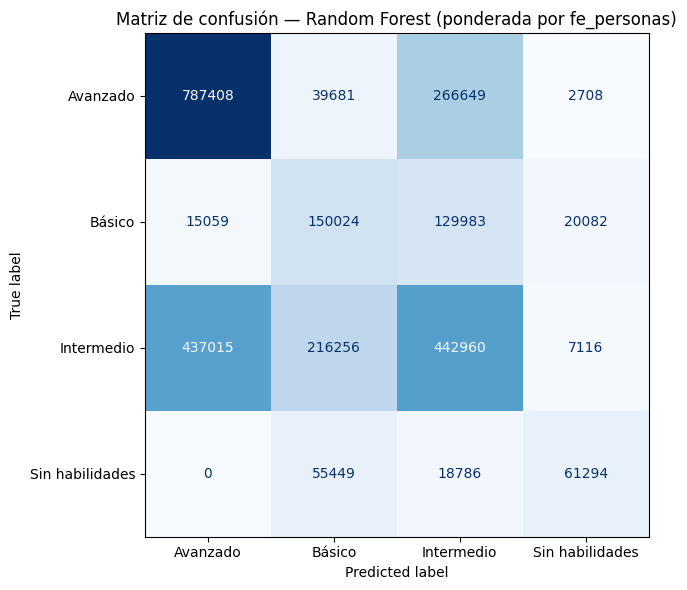

In [27]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred, sample_weight=w_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".0f")
ax.set_title(f"Matriz de confusión — {mejor_nombre} (ponderada por fe_personas)")
plt.tight_layout()
plt.show()

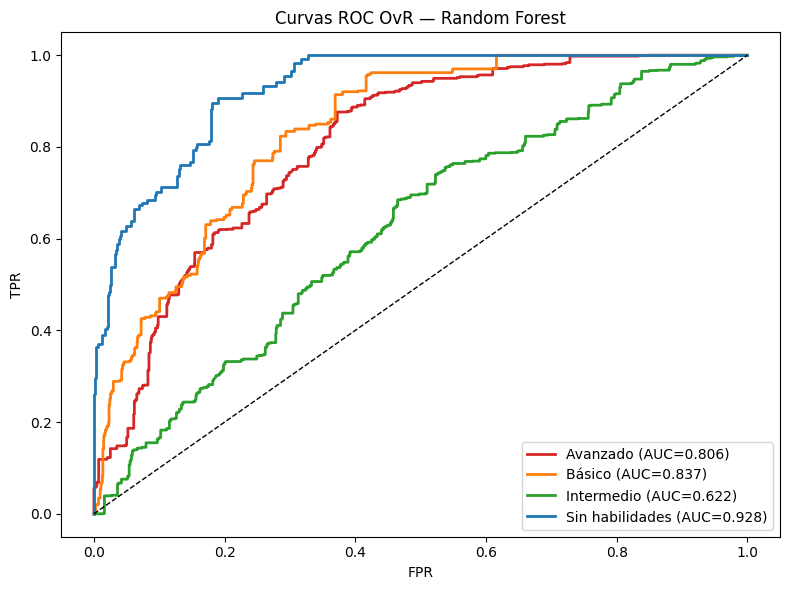

In [28]:
# Curvas ROC one-vs-rest
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
colores_roc = ["#d62728","#ff7f0e","#2ca02c","#1f77b4"]
fig, ax = plt.subplots(figsize=(8, 6))
for i, clase in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i], sample_weight=w_test)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colores_roc[i], lw=2, label=f"{clase} (AUC={roc_auc:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title(f"Curvas ROC OvR — {mejor_nombre}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

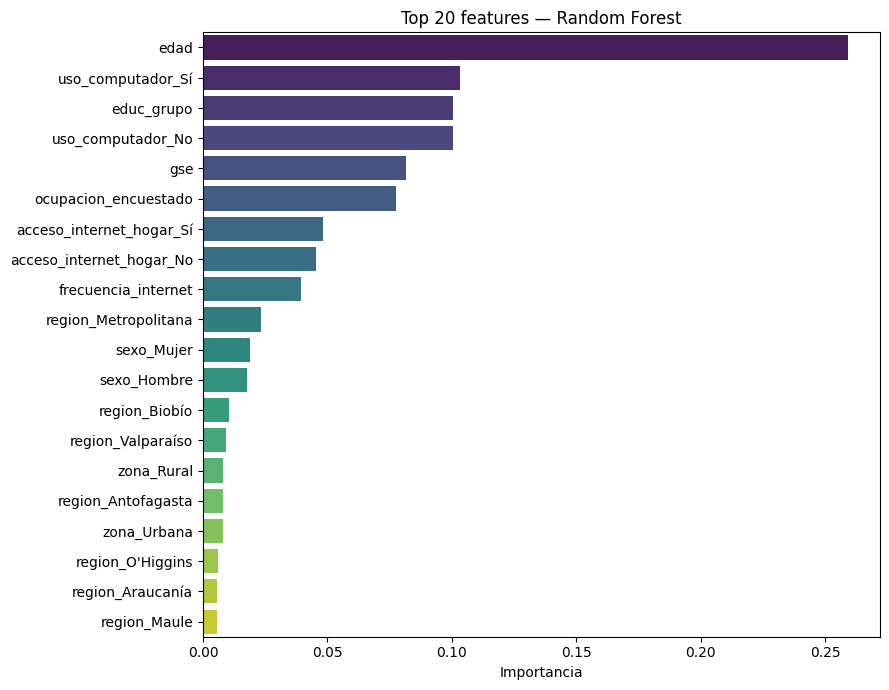


Top 20 importancia — Random Forest
----------------------------------
feature                   importance
------------------------------------
edad                            0.26
uso_computador_Sí               0.10
educ_grupo                      0.10
uso_computador_No               0.10
gse                             0.08
ocupacion_encuestado            0.08
acceso_internet_hogar_Sí        0.05
acceso_internet_hogar_No        0.05
frecuencia_internet             0.04
region_Metropolitana            0.02
sexo_Mujer                      0.02
sexo_Hombre                     0.02
region_Biobío                   0.01
region_Valparaíso               0.01
zona_Rural                      0.01
region_Antofagasta              0.01
zona_Urbana                     0.01
region_O'Higgins                0.01
region_Araucanía                0.01
region_Maule                    0.01


In [29]:
# Feature importance del mejor modelo
nombres_num = feature_numerica
nombres_onehot = list(
    pipe_final.named_steps["prep"]
    .named_transformers_["cat_nominal"]
    .named_steps["onehot"]
    .get_feature_names_out(features_nominales)
)
nombres_features_final = nombres_num + nombres_onehot + nombres_ordinales

clf = pipe_final.named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    importancias = clf.feature_importances_
else:
    importancias = np.linalg.norm(clf.coef_, axis=0)

df_imp = pd.DataFrame({"feature": nombres_features_final,
                       "importance": importancias}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=df_imp.head(20), x="importance", y="feature", palette="viridis", ax=ax)
ax.set_title(f"Top 20 features — {mejor_nombre}")
ax.set_xlabel("Importancia"); ax.set_ylabel("")
plt.tight_layout()
plt.show()
print()
_top_imp = df_imp.set_index("feature").round(4)
print(to_pretty(_top_imp.head(20), titulo=f"Top 20 importancia — {mejor_nombre}"))

### 9.4 Regresión logística — coeficientes con dirección

Permite leer signo y magnitud, complementando al modelo de árboles.

In [30]:
# Logistic Regression entrenada sobre los mismos splits, ponderada
pipe_lr = Pipeline([("prep", preprocesador),
                    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                                random_state=42, C=1.0))])
pipe_lr.fit(X_train, y_train, clf__sample_weight=w_train)
y_pred_lr = pipe_lr.predict(X_test)
print("Classification report — Logistic Regression:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Classification report — Logistic Regression:
                 precision    recall  f1-score   support

       Avanzado       0.67      0.66      0.66       310
         Básico       0.34      0.58      0.43       161
     Intermedio       0.61      0.40      0.48       445
Sin habilidades       0.33      0.50      0.40        84

       accuracy                           0.52      1000
      macro avg       0.49      0.54      0.49      1000
   weighted avg       0.56      0.52      0.52      1000



In [31]:
# Coeficientes para la clase "Avanzado"
clf_lr = pipe_lr.named_steps["clf"]
prep_lr = pipe_lr.named_steps["prep"]
nombres_onehot_lr = list(
    prep_lr.named_transformers_["cat_nominal"]
    .named_steps["onehot"].get_feature_names_out(features_nominales))
nombres_lr = feature_numerica + nombres_onehot_lr + nombres_ordinales

idx_av = list(le.classes_).index("Avanzado")
coefs_av = clf_lr.coef_[idx_av]

df_coef = pd.DataFrame({"Feature": nombres_lr, "Coeficiente": coefs_av})
df_coef["Direccion"] = np.where(df_coef["Coeficiente"] >= 0, "Positiva", "Negativa")
df_coef["Magnitud"]  = df_coef["Coeficiente"].abs()
df_coef = df_coef.sort_values("Magnitud", ascending=False).reset_index(drop=True)
_top_coef = df_coef.head(20).set_index("Feature").round(4)
print(to_pretty(_top_coef, titulo="Top 20 coeficientes para clase 'Avanzado'"))

Top 20 coeficientes para clase 'Avanzado'
-----------------------------------------
Feature                    Coeficiente  Direccion  Magnitud
-----------------------------------------------------------
uso_computador_No                -1.58   Negativa      1.58
acceso_internet_hogar_No         -1.32   Negativa      1.32
edad                             -1.00   Negativa      1.00
region_Antofagasta               -0.91   Negativa      0.91
educ_grupo                        0.87   Positiva      0.87
region_Aysén                     -0.87   Negativa      0.87
region_Arica y Parinacota        -0.86   Negativa      0.86
region_Los Ríos                  -0.84   Negativa      0.84
sexo_Mujer                       -0.77   Negativa      0.77
zona_Rural                       -0.76   Negativa      0.76
frecuencia_internet               0.75   Positiva      0.75
zona_Urbana                      -0.71   Negativa      0.71
sexo_Hombre                      -0.69   Negativa      0.69
region_Biobío   

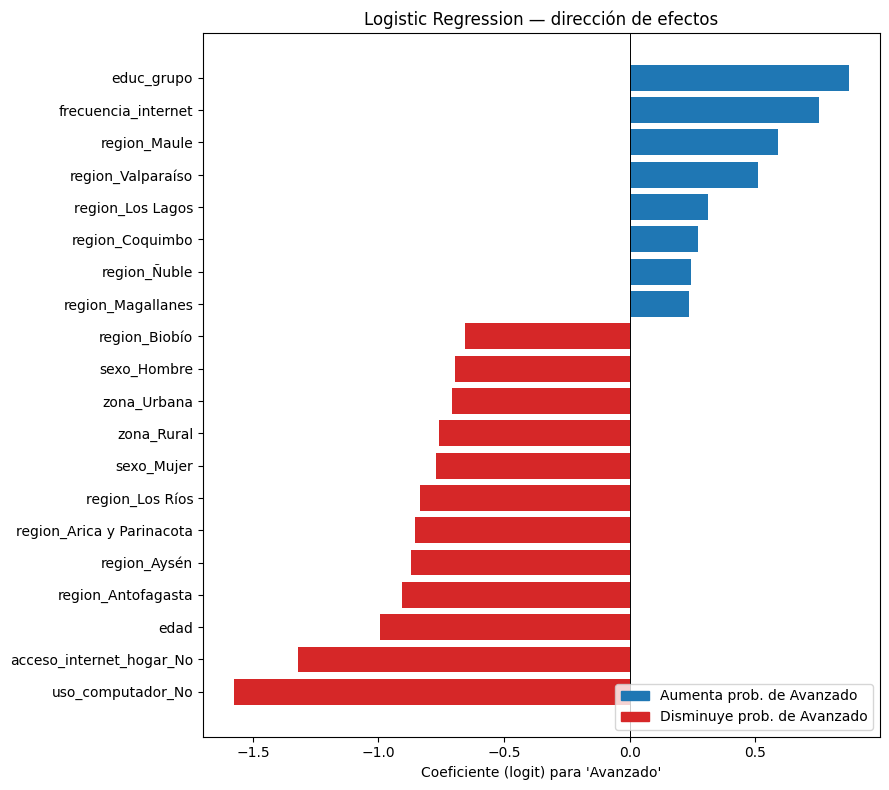

In [32]:
# Bar plot horizontal — top 20 por magnitud
top_n = 20
top = df_coef.head(top_n).copy()
top["color"] = np.where(top["Direccion"] == "Positiva", "#1f77b4", "#d62728")
top = top.sort_values("Coeficiente")

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top["Feature"], top["Coeficiente"], color=top["color"])
ax.axvline(0, color="black", lw=0.7)
ax.set_xlabel("Coeficiente (logit) para 'Avanzado'")
ax.set_title("Logistic Regression — dirección de efectos")
positivo = mpatches.Patch(color="#1f77b4", label="Aumenta prob. de Avanzado")
negativo = mpatches.Patch(color="#d62728", label="Disminuye prob. de Avanzado")
ax.legend(handles=[positivo, negativo], loc="lower right")
plt.tight_layout()
plt.show()

### 9.5 SHAP — Interpretabilidad

In [33]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "shap"])
    import shap

# Solo si el mejor modelo es de árboles (RF/GBM) — si es LogReg, usar KernelExplainer.
clf_best = pipe_final.named_steps["clf"]
prep = pipe_final.named_steps["prep"]
X_test_trans = prep.transform(X_test)
feature_names_shap = nombres_features_final

if hasattr(clf_best, "estimators_") or "Boost" in type(clf_best).__name__:
    explainer = shap.TreeExplainer(clf_best)
    shap_values_all = explainer.shap_values(X_test_trans)
    idx_av = list(le.classes_).index("Avanzado")
    # shap_values_all puede ser lista (sklearn classic) o array 3D
    if isinstance(shap_values_all, list):
        sv = shap_values_all[idx_av]
    else:
        sv = shap_values_all[:, :, idx_av] if shap_values_all.ndim == 3 else shap_values_all
    print(f"SHAP values shape: {sv.shape}")
else:
    print("Modelo no es de árboles — saltando SHAP (usar KernelExplainer si se requiere).")
    sv = None

SHAP values shape: (1000, 29)


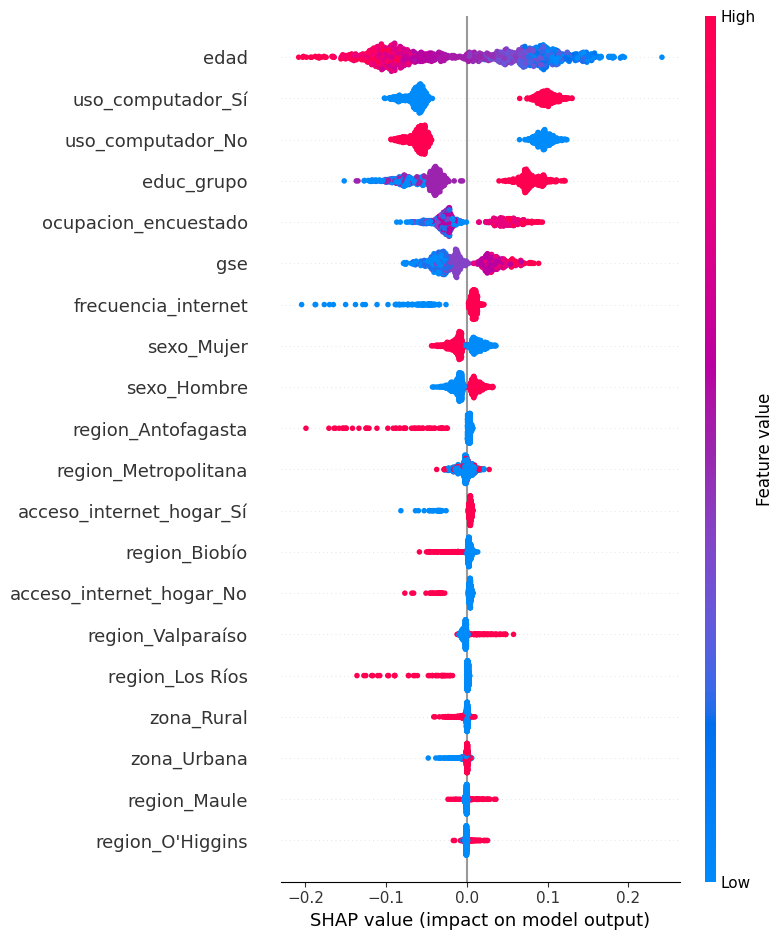

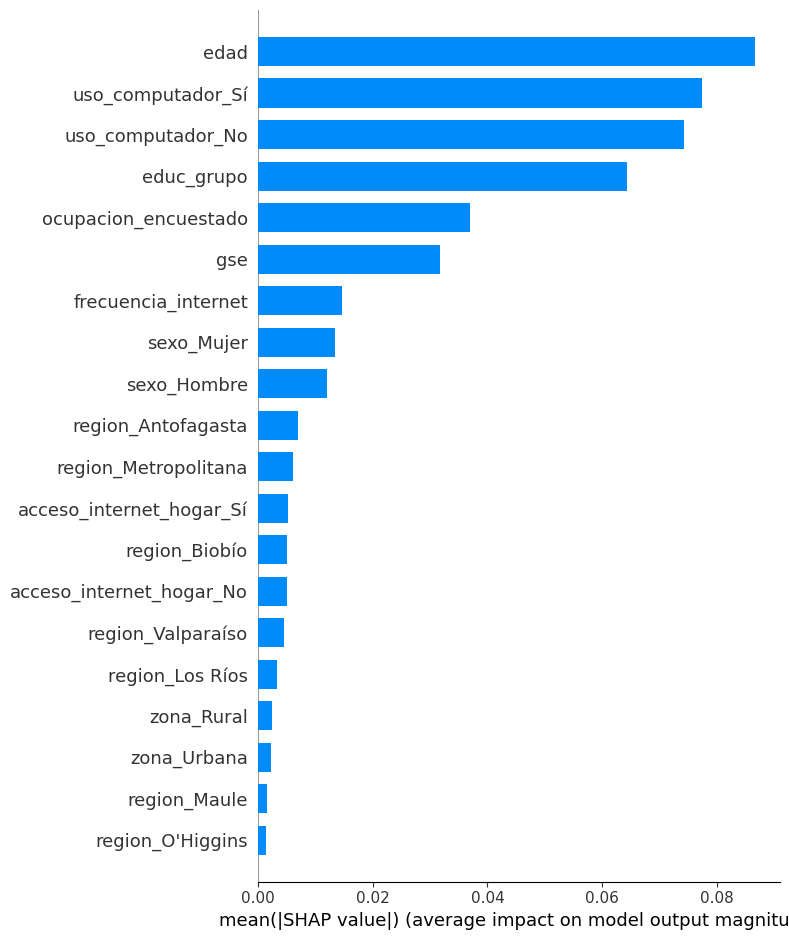

Ranking SHAP top-20 (clase 'Avanzado')
--------------------------------------
feature                   shap_mean_abs
---------------------------------------
edad                               0.09
uso_computador_Sí                  0.08
uso_computador_No                  0.07
educ_grupo                         0.06
ocupacion_encuestado               0.04
gse                                0.03
frecuencia_internet                0.01
sexo_Mujer                         0.01
sexo_Hombre                        0.01
region_Antofagasta                 0.01
region_Metropolitana               0.01
acceso_internet_hogar_Sí           0.01
region_Biobío                      0.01
acceso_internet_hogar_No           0.01
region_Valparaíso                  0.00
region_Los Ríos                    0.00
zona_Rural                         0.00
zona_Urbana                        0.00
region_Maule                       0.00
region_O'Higgins                   0.00


In [34]:
# Beeswarm plot + bar plot (solo si hay SHAP values)
if sv is not None:
    shap.summary_plot(sv, X_test_trans, feature_names=feature_names_shap, show=False)
    plt.tight_layout(); plt.show()

    shap.summary_plot(sv, X_test_trans, feature_names=feature_names_shap,
                      plot_type="bar", show=False)
    plt.tight_layout(); plt.show()

    # Ranking SHAP vs Feature Importance
    importancia_shap = np.abs(sv).mean(axis=0)
    df_shap_rank = pd.DataFrame({
        "feature": feature_names_shap,
        "shap_mean_abs": importancia_shap
    }).sort_values("shap_mean_abs", ascending=False)
    _shap_rk = df_shap_rank.set_index("feature").round(4)
    print(to_pretty(_shap_rk.head(20), titulo="Ranking SHAP top-20 (clase 'Avanzado')"))

## 10. Conclusiones — checklist de salidas

- Descriptiva univariada/bivariada: tabuladas en texto plano (copy/paste a Word o Excel).
- Inferencial: chi-cuadrado y V de Cramér para los pares clave.
- MCA + K-Means: dimensiones latentes de habilidades y clusters etiquetados por GSE/zona.
- EFA: factores subyacentes de las 18 habilidades Q8.
- ML supervisado: LogReg/RF/GBM con `fe_personas` como `sample_weight` y comparación CV.
- Regresión logística: dirección de efectos para clase 'Avanzado'.
- SHAP: importancia direccional sobre el mejor modelo.